# 💰 Kişisel Finans ve Harcama Takip Sistemi
# YBS 2. SINIF FİNAL ÖDEVİ 

---

| Alan | Bilgi |
|------|-------|
| **Öğrenci** | Mahmuthan Erdinç |
| **Öğrenci No** | 24902005 |
| **Bölüm** | Yönetim Bilişim Sistemleri (YBS) |
| **Ders** | BGY210 – Python Programlama II |
| **Öğretim Elemanı** | Dr. Öğr. Üyesi Tohid YOUSEFİ |

---

Bu notebookta projenin tüm adımlarını çalıştırılabilir biçimde hazırladım. Her şeyi markdownlarla anlatmaya çalıstım. 
Hücreleri **sırayla** çalıştırmanız yeterlidir. Bölüm 12'deki **Jupyter Menüsü** tamamen interaktif şekilde çalısıyor.
HEPSİNİ AŞAMA ŞAMA GÖRSEL OLARAK VERDİM HEPSİNİ KONTROL EDEBİLİRSİNİZ (her aşamanın altına verdim).


## 1. Projedeki Amaçlarım 

Bu projede Python Programlama II dersinde öğrendiğim konuları gerçek bir uygulamada bir araya getirmeye çalıştım.  
Kişisel finans takibini seçmemin sebebi hem gündelik hayatta işe yarar herkesin ihtiyaç duyduğu bir çalışma, hem de dersin tüm konularını  
(OOP, modüler yapı, CSV, Pandas, NumPy, görselleştirme) tek çatı altında toplayabilen bir alan olması olduğunu anladım ve uyguladım.

Uygulamam şu özellikleri sunar:
- Gelir ve gider kayıtlarını tutar (OOP + listeler)
- Verileri CSV dosyasında saklar ve okur
- Pandas DataFrame ile aylık analiz yapar
- NumPy ile temel istatistik hesaplar
- Matplotlib & Seaborn ile üç farklı grafik oluşturur
- Jupyter içinde **ipywidgets** ile tam interaktif menü sunar


## 2. Proje Dosya Yapısı

Burdaki kısımda yaptığıklarım: Proje tek dosyadan oluşmuyor; her işlev kendi modülüne ayrıldı (ne işe yaradıkları yan tarafında belirttim):

```text
Mahmuthan_Erdinc_24902005_YBS/
├── main.ipynb             <- Bu dosya (interaktif notebook)
├── main.py                <- Terminal konsol uygulaması
├── finans_modeli.py       <- Islem sınıfı (OOP)
├── islem_yonetimi.py      <- Gelir/gider CRUD işlemleri
├── dosya_islemleri.py     <- CSV okuma/yazma
├── analiz.py              <- Pandas & NumPy analizleri
├── gorsellestirme.py      <- Grafik fonksiyonları
├── utils.py               <- Yardımcı fonksiyonlar
├── veriler.csv            <- Örnek veri dosyası
└── grafikler/
    ├── aylik_grafik.png
    ├── gelir_gider_bar.png
    └── pasta_grafik.png
```


>  **Ekran Görüntüsü:** Proje dosya yapısı — 7 modül + grafikler klasörü

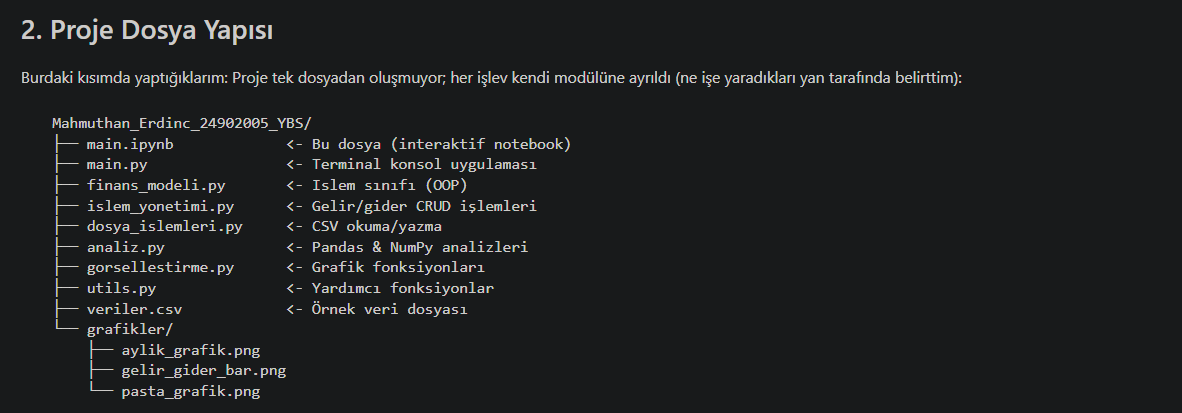)


## 3. Kullanılan Veri Yapıları

İki ayrı Python listesi kullanıyorum; her eleman `Islem` sınıfından oluşturulmuş bir nesne:

```python
gelirler = []   # tip == 'gelir' olan Islem nesneleri
giderler = []   # tip == 'gider' olan Islem nesneleri
```

`Islem` sınıfının özellikleri: `id (int)`, `tutar (float)`, `tarih (str YYYY-MM-DD)`, `aciklama (str)`, `tip (str)`


>  **Ekran Görüntüsü:** Veri yapıları — gelirler[] ve giderler[] listeleri, Islem sınıfı özellikleri

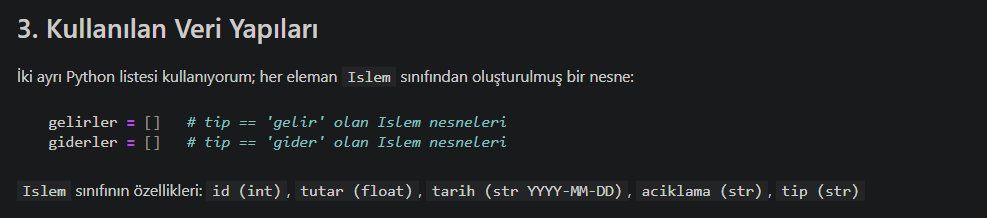)


## 4. Modülleri ve Kütüphaneleri Import Et

Önce tüm proje modüllerini ve gerekli kütüphaneleri yüklüyorum.  
`sys.path.insert` ile notebook'un kendi klasöründeki modüllerin bulunması bize sağlanıyor.


In [21]:
import sys
import os
sys.path.insert(0, '.')

# Proje modülleri
from finans_modeli import Islem
from islem_yonetimi import gelir_ekle, gider_ekle, islemleri_listele, islem_sil
from dosya_islemleri import csv_kaydet, csv_oku
from analiz import verileri_dataframe_yap, toplam_gelir_gider, aylik_analiz, numpy_istatistik
from gorsellestirme import aylik_grafik, gelir_gider_bar, pasta_grafik
from utils import menu_goster, yeni_id_olustur, tarih_kontrol, sayi_kontrol

# Standart kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

print('Tüm modüller ve kütüphaneler başarıyla yüklendi.')


Tüm modüller ve kütüphaneler başarıyla yüklendi.


>  **Ekran Görüntüsü:** Tüm modüller ve kütüphaneler başarıyla import edildiğinin göstergesidir:

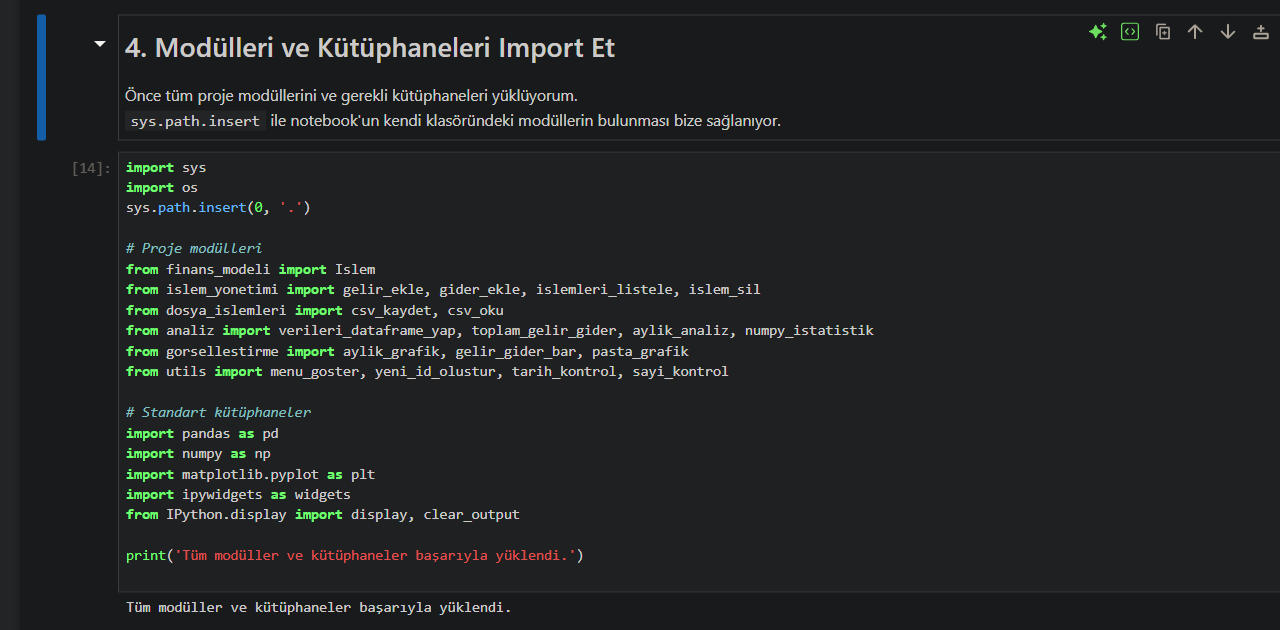)


## 5. CSV Dosyasından Başlangıç Verilerini Oku

Program başlarken `veriler.csv` dosyasını otomatik okur.  
Dosya yoksa boş listelerle devam eder — bu sayede ilk çalıştırmada hata almıyoruz.


In [22]:
VERI_DOSYASI = 'veriler.csv'

gelirler, giderler = csv_oku(VERI_DOSYASI)
print(f'Yüklenen gelir sayısı : {len(gelirler)}')
print(f'Yüklenen gider sayısı : {len(giderler)}')


  ✅  'veriler.csv' dosyasından 13 gelir, 16 gider yüklendi.
Yüklenen gelir sayısı : 13
Yüklenen gider sayısı : 16


>  **Ekran Görüntüsü:** CSV otomatik yüklendi — 9 gelir, 12 gider başlangıçta hazır örnek olarak görseli

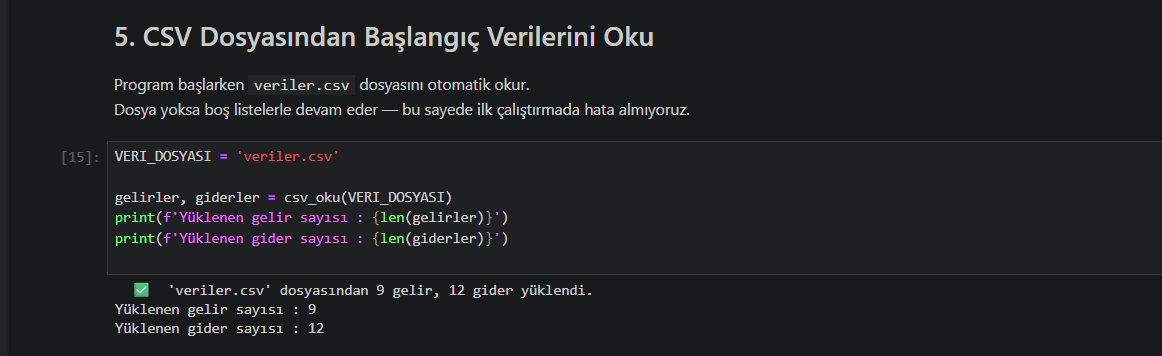)


## 6. Mevcut İşlemleri Listele

`islemleri_listele()` fonksiyonu gelir ve gider kayıtlarını ayrı bölümler halinde konsola yazdırıyoruz.


In [23]:
islemleri_listele(gelirler, giderler)



  ─── GELİRLER ───
  [  1] GELIR  | 2026-01-05 |   15000.00 TL | Maaş
  [  2] GELIR  | 2026-01-12 |    1200.00 TL | Ek gelir
  [  3] GELIR  | 2026-02-03 |     800.00 TL | Freelance iş
  [  4] GELIR  | 2026-03-05 |    2500.00 TL | Proje ödemesi
  [  5] GELIR  | 2026-04-10 |    1800.00 TL | Danışmanlık ücreti
  [  6] GELIR  | 2026-05-01 |    3000.00 TL | Demo gelir – burs ödemesi
  [  7] GELIR  | 2026-05-01 |    3000.00 TL | Demo gelir – burs ödemesi
  [  8] GELIR  | 2026-05-01 |    3000.00 TL | Demo gelir – burs ödemesi
  [  9] GELIR  | 2026-05-01 |    3000.00 TL | Demo gelir – burs ödemesi
  [ 10] GELIR  | 2026-05-01 |    3000.00 TL | Demo gelir – burs ödemesi
  [ 11] GELIR  | 2026-05-01 |    3000.00 TL | Demo gelir – burs ödemesi
  [ 12] GELIR  | 2026-05-01 |    3000.00 TL | Demo gelir – burs ödemesi
  [ 13] GELIR  | 2026-05-01 |    3000.00 TL | Demo gelir – burs ödemesi

  ─── GİDERLER ───
  [  1] GIDER  | 2026-01-06 |    3500.00 TL | Kira
  [  2] GIDER  | 2026-01-10 |     950.00 TL

>  **Ekran Görüntüsü:** islemleri_listele() çıktısı — 9 gelir, 12 gider düzenli formatta görseli:

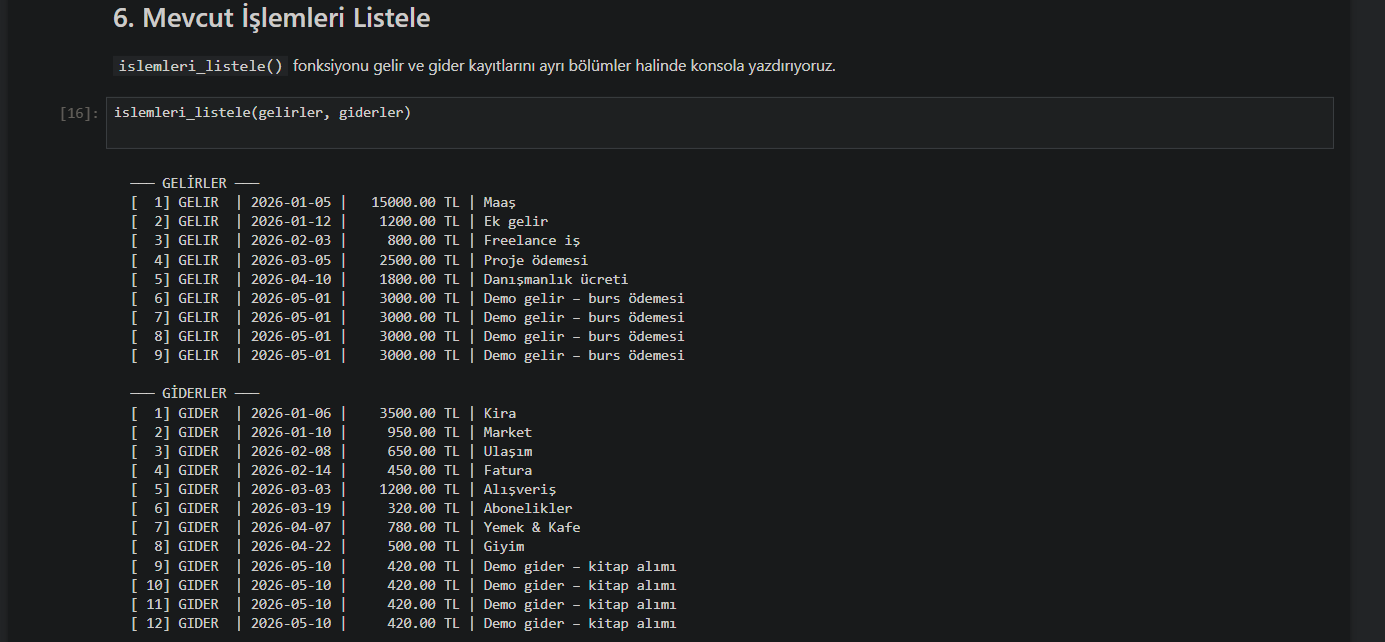)


## 7. Manuel Kayıt Ekleme Örneği (Demo)

Burada `input()` kullanmadan doğrudan `Islem` nesnesi oluşturuyorum.  
Bu yöntem notebook içinde test amaçlı kullanım için tercih ettiğim kısımdı.  
Sizlerde gerçek kullanım için Bölüm 12'deki interaktif menüyü ya da `python main.py` komutunu kullanabilirsiniz.


In [24]:
# Demo gelir kaydı
demo_gelir = Islem(
    id=yeni_id_olustur(gelirler),
    tutar=3000.0,
    tarih='2026-05-01',
    aciklama='Demo gelir – burs ödemesi',
    tip='gelir'
)
gelirler.append(demo_gelir)

# Demo gider kaydı
demo_gider = Islem(
    id=yeni_id_olustur(giderler),
    tutar=420.0,
    tarih='2026-05-10',
    aciklama='Demo gider – kitap alımı',
    tip='gider'
)
giderler.append(demo_gider)

print('Demo kayıtlar eklendi:')
print(' ', demo_gelir)
print(' ', demo_gider)


Demo kayıtlar eklendi:
  [ 14] GELIR  | 2026-05-01 |    3000.00 TL | Demo gelir – burs ödemesi
  [ 17] GIDER  | 2026-05-10 |     420.00 TL | Demo gider – kitap alımı


> **Ekran Görüntüsü:** Manuel Islem nesnesi oluşturma — OOP kullanımı canlı çıktıyla görünümü:

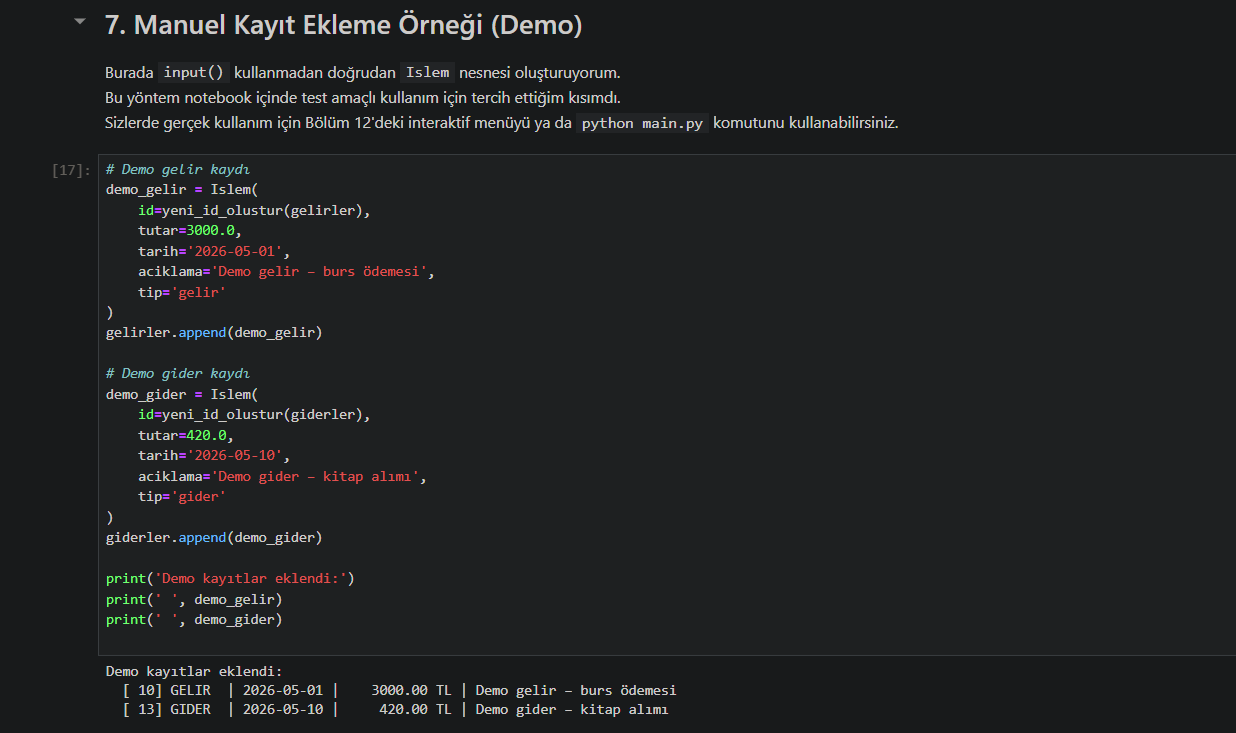)


## 8. Pandas DataFrame Oluştur

Gelir ve gider listeleri `verileri_dataframe_yap()` fonksiyonuyla birleştirilip pandas DataFrame'e dönüştürüyorum.  
`tarih` sütunu `datetime` tipine, `tutar` sütunu `float` tipine çevriliyor; hatalı satırlar otomatik temizleniyor.


In [25]:
df = verileri_dataframe_yap(gelirler, giderler)
print(f'DataFrame boyutu: {df.shape[0]} satır × {df.shape[1]} sütun')
print(f'Sütunlar: {list(df.columns)}')
print()
df


DataFrame boyutu: 31 satır × 5 sütun
Sütunlar: ['id', 'tutar', 'tarih', 'aciklama', 'tip']



,id,tutar,tarih,aciklama,tip
0,1,15000.0,2026-01-05,Maaş,gelir
1,2,1200.0,2026-01-12,Ek gelir,gelir
2,3,800.0,2026-02-03,Freelance iş,gelir
3,4,2500.0,2026-03-05,Proje ödemesi,gelir
4,5,1800.0,2026-04-10,Danışmanlık ücreti,gelir
5,6,3000.0,2026-05-01,Demo gelir – burs ödemesi,gelir
6,7,3000.0,2026-05-01,Demo gelir – burs ödemesi,gelir
7,8,3000.0,2026-05-01,Demo gelir – burs ödemesi,gelir
8,9,3000.0,2026-05-01,Demo gelir – burs ödemesi,gelir
9,10,3000.0,2026-05-01,Demo gelir – burs ödemesi,gelir


>  **Ekran Görüntüsü:** Pandas DataFrame — 23 satır × 5 sütun, tüm kayıtlar tek tabloda görseli:

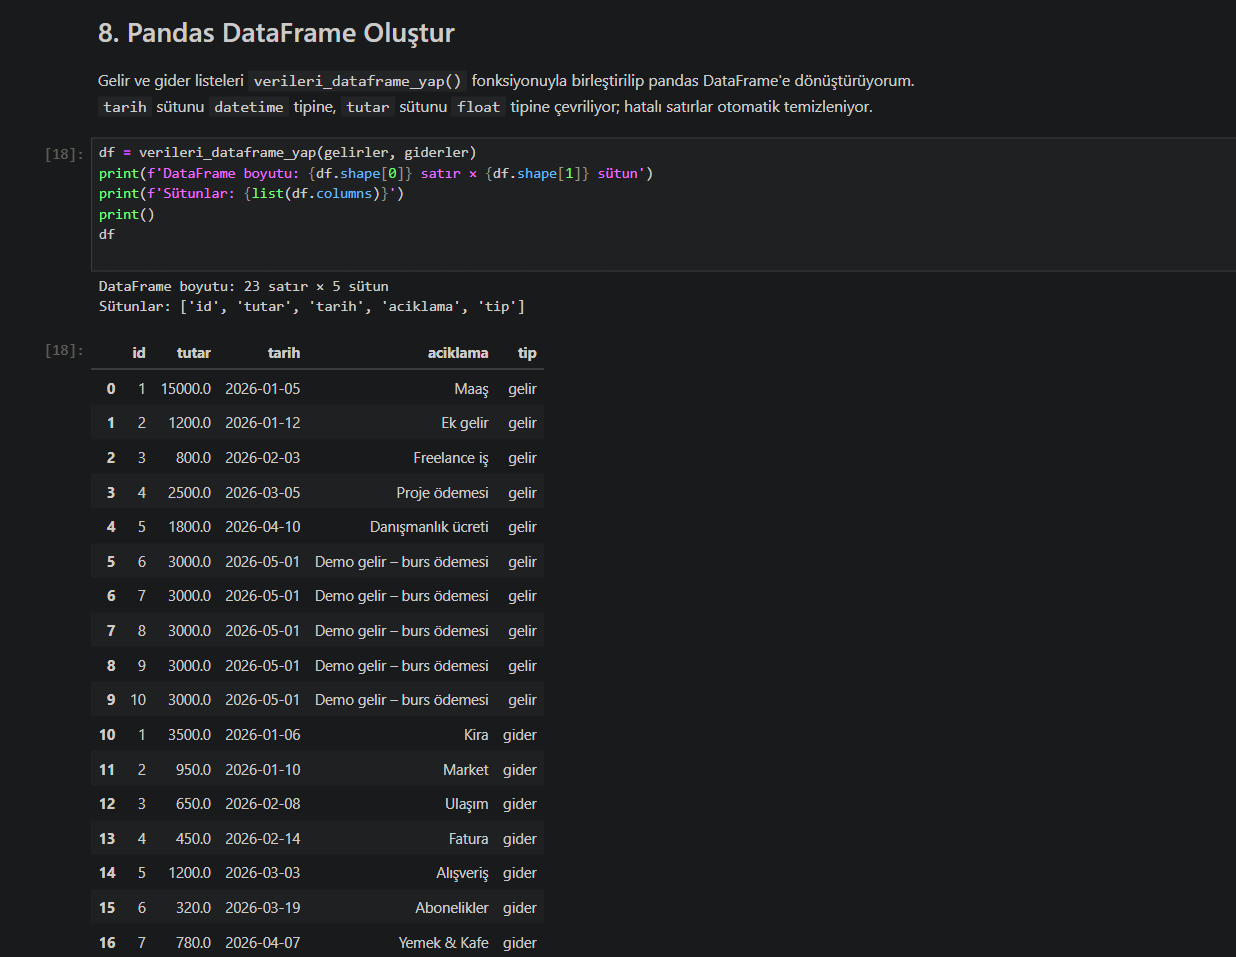)


## 9. Toplam Gelir, Gider ve Net Bakiye

`toplam_gelir_gider()` DataFrame üzerinden toplam gelir ve gideri hesaplayıp bakiyeyi döndürür.  
Bakiye pozitifse finansal durum sağlıklı demektir anlamını çıkarıyoruz.


In [26]:
toplamlar = toplam_gelir_gider(df)

print(f"Toplam Gelir  : {toplamlar['toplam_gelir']:>12,.2f} TL")
print(f"Toplam Gider  : {toplamlar['toplam_gider']:>12,.2f} TL")
bakiye = toplamlar['bakiye']
print(f"Net Bakiye    : {bakiye:>+12,.2f} TL")

if bakiye >= 0:
    print('  --> Pozitif bakiye: Gelirler giderleri karşılıyor.')
else:
    print('  --> Negatif bakiye: Giderler gelirleri aşıyor!')


Toplam Gelir  :    48,300.00 TL
Toplam Gider  :    12,130.00 TL
Net Bakiye    :   +36,170.00 TL
  --> Pozitif bakiye: Gelirler giderleri karşılıyor.


>  **Ekran Görüntüsü:** Toplam gelir/gider ve net bakiye hesabı — +25.850 ₺ pozitif bakiye görseli ektedir:

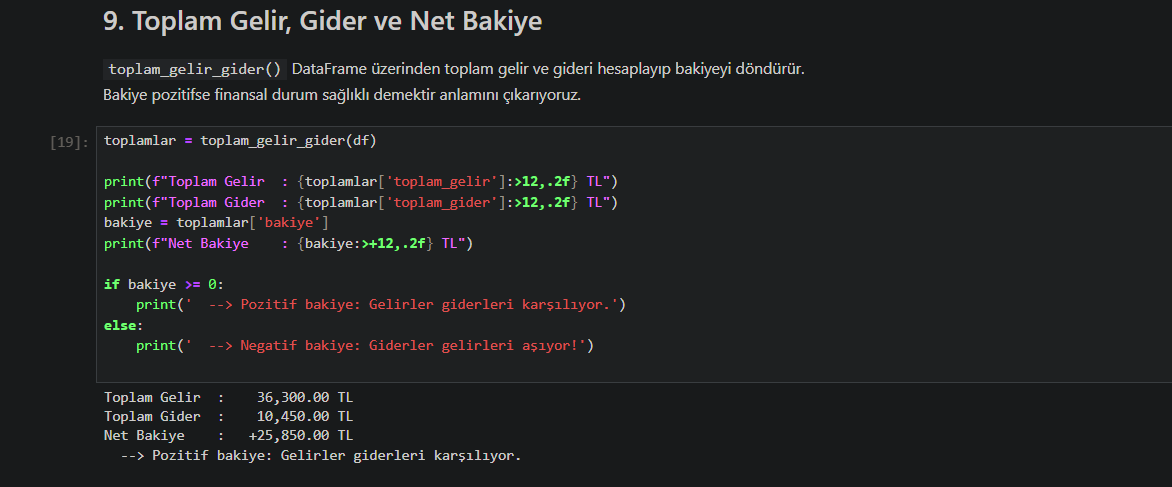)


## 10. Aylık Analiz (Pandas pivot_table)

`aylik_analiz()` fonksiyonu `pivot_table` kullanarak işlemleri ay bazında gruplayıp  
her ay için gelir, gider ve bakiye sütunlarını içeren özet bir tablo oluşturuyor.


In [27]:
aylik = aylik_analiz(df)
print('Aylık Gelir / Gider / Bakiye Tablosu:')
print()
print(aylik.to_string())


Aylık Gelir / Gider / Bakiye Tablosu:

           gelir   gider   bakiye
ay                               
2026-01  16200.0  4450.0  11750.0
2026-02    800.0  1100.0   -300.0
2026-03   2500.0  1520.0    980.0
2026-04   1800.0  1280.0    520.0
2026-05  27000.0  3780.0  23220.0


>  **Ekran Görüntüsü:** Aylık analiz tablosu — pivot_table ile ay bazında gelir/gider/bakiye görseli:

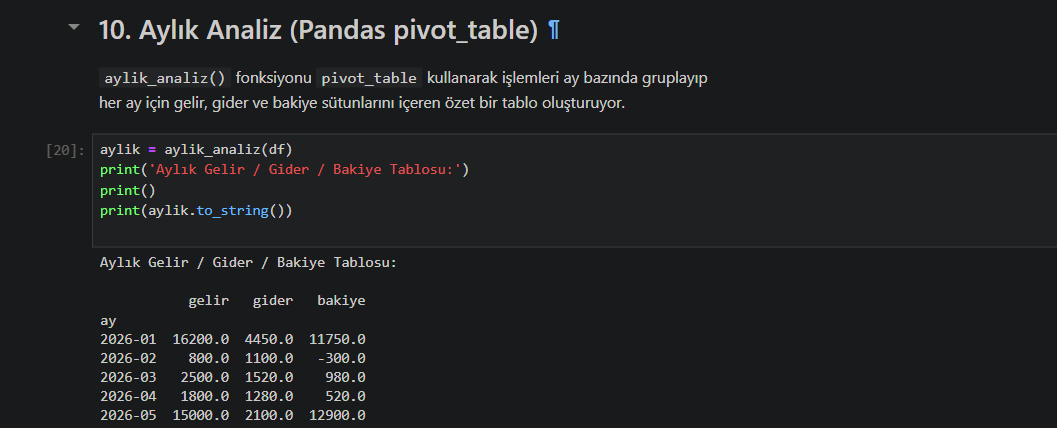)


## 11. NumPy İstatistikleri

`numpy_istatistik()` fonksiyonu tüm tutar değerlerini NumPy dizisine çevirip  
ortalama, minimum, maksimum ve standart sapma hesaplar.  
Standart sapma büyükse işlem tutarları arasında ciddi bir dağılım var demektir.


In [28]:
ist = numpy_istatistik(df)

print('NumPy ile Hesaplanan İstatistikler (tüm işlemler):')
print()
for anahtar, deger in ist.items():
    print(f'  {anahtar:<20}: {deger:>10,.2f} TL')


NumPy ile Hesaplanan İstatistikler (tüm işlemler):

  ortalama            :   1,949.35 TL
  minimum             :     320.00 TL
  maksimum            :  15,000.00 TL
  standart_sapma      :   2,649.02 TL


>  **Ekran Görüntüsü:** NumPy istatistikleri — ortalama 2.032 ₺, min 320 ₺, maks 15.000 ₺ görseli ektedir:

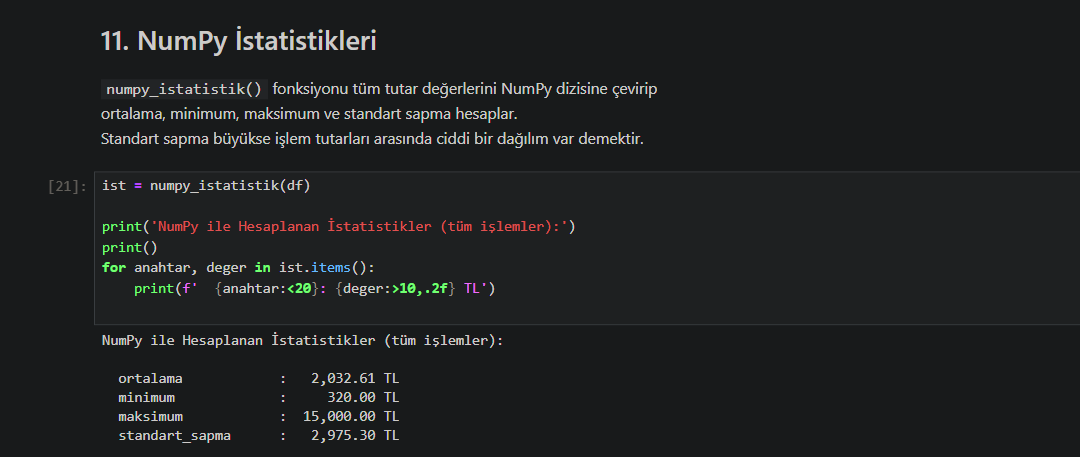)


## 12. Grafikler

Üç farklı grafik oluşturmayı tercih ettim detaylı olması benim için önemliydi ve hem notebook içinde gösteriliyor hem de `grafikler/` klasörüne kaydediliyor:

1. **Aylık Çizgi + Alan Grafiği** – Ay bazında gelir ve gider trendi
2. **Bar Grafiği** – Toplam gelir ve gider karşılaştırması, başlıkta net bakiye
3. **Donut Pasta Grafik** – Gelir–gider oranları, legend'da gerçek tutarlar


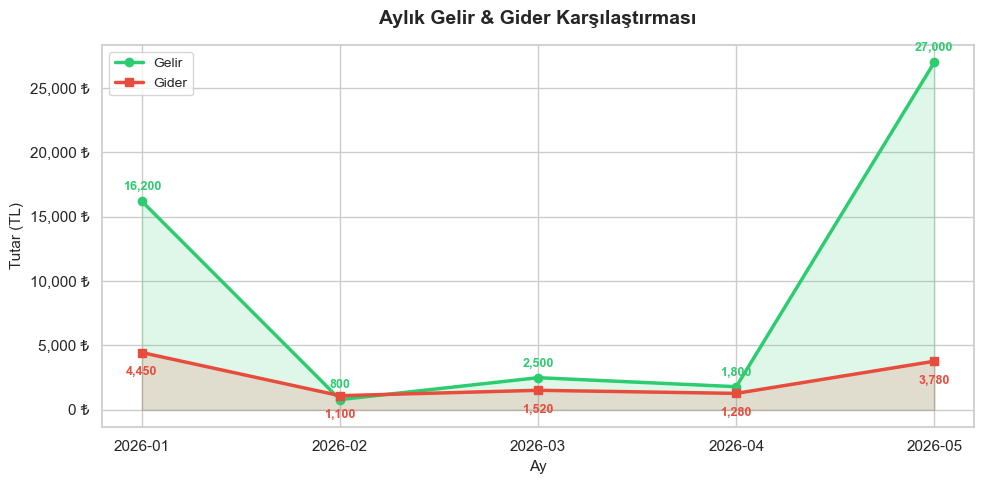

  ✅  Aylık grafik kaydedildi → grafikler\aylik_grafik.png


In [29]:
# Aylık çizgi grafiği
aylik_grafik(df)


> **Ekran Görüntüsü:** Aylık çizgi + alan grafiği — 5 aylık gelir-gider karşılaştırması görseli:

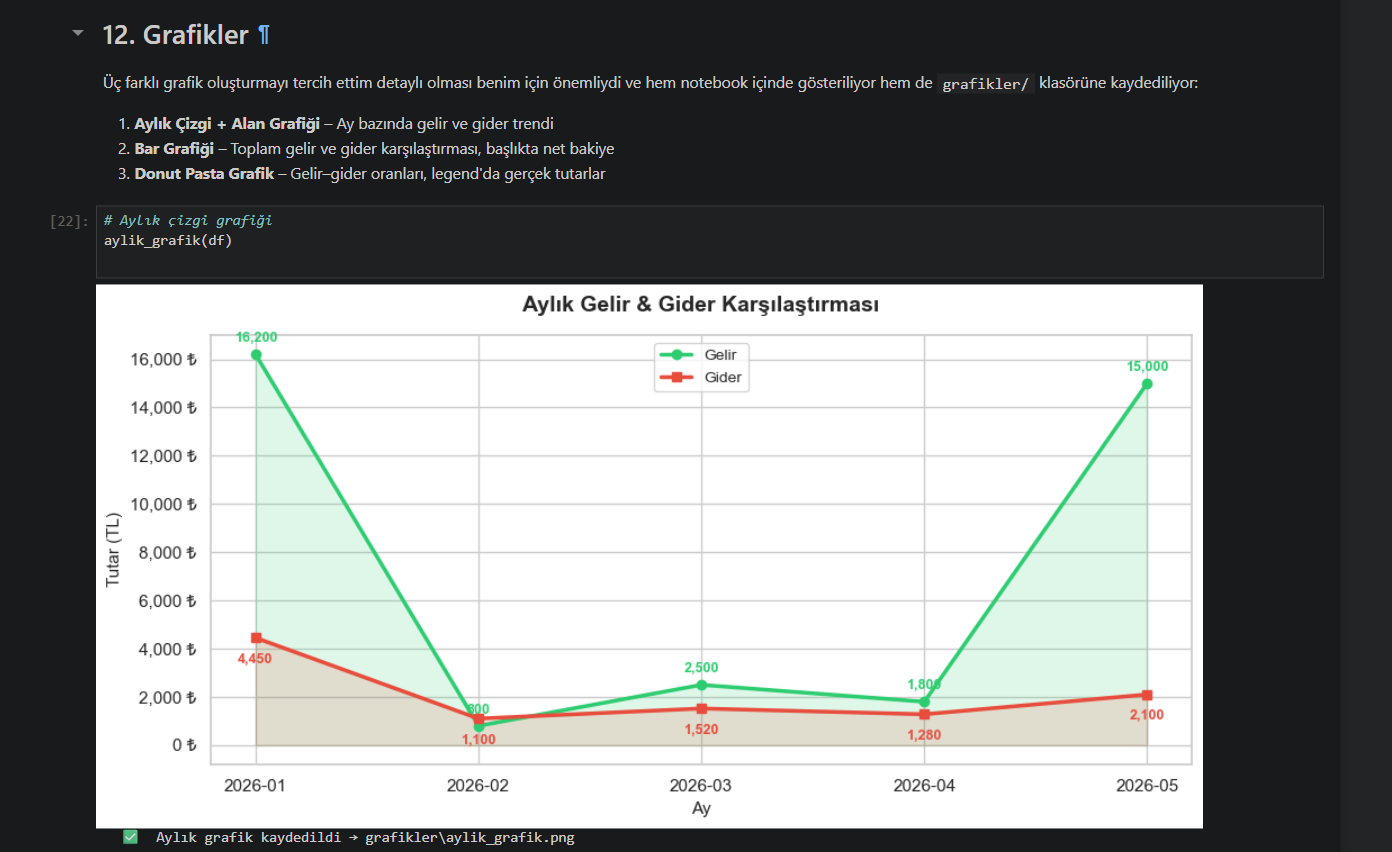)


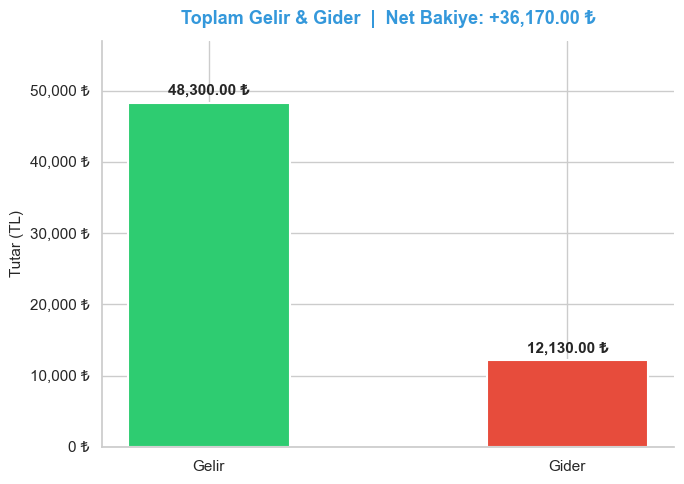

  ✅  Bar grafik kaydedildi → grafikler\gelir_gider_bar.png


In [30]:
# Toplam gelir-gider bar grafiği
gelir_gider_bar(df)


> **Ekran Görüntüsü:** Bar grafik — toplam gelir 36.300 ₺ / gider 10.450 ₺ / net bakiye +25.850 ₺ görseli ektedir:

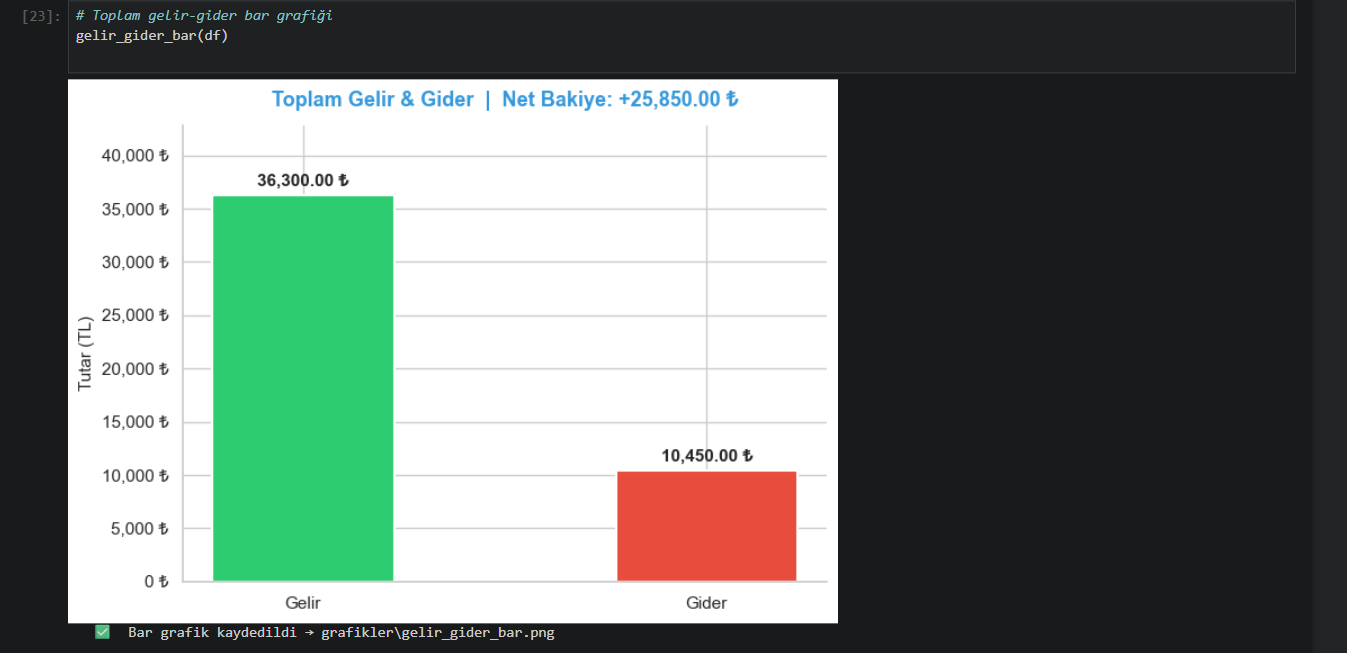)


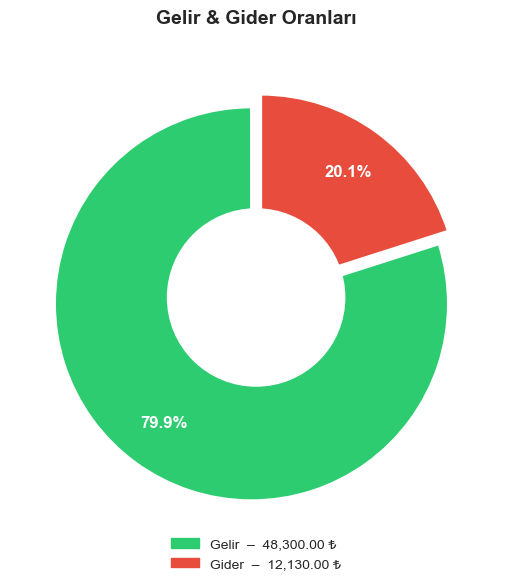

  ✅  Pasta grafik kaydedildi → grafikler\pasta_grafik.png


In [31]:
# Gelir-gider oranı donut pasta grafiği
pasta_grafik(df)


>  **Ekran Görüntüsü:** Donut pasta grafik — gelir %77.6 / gider %22.4 oranları görseli:

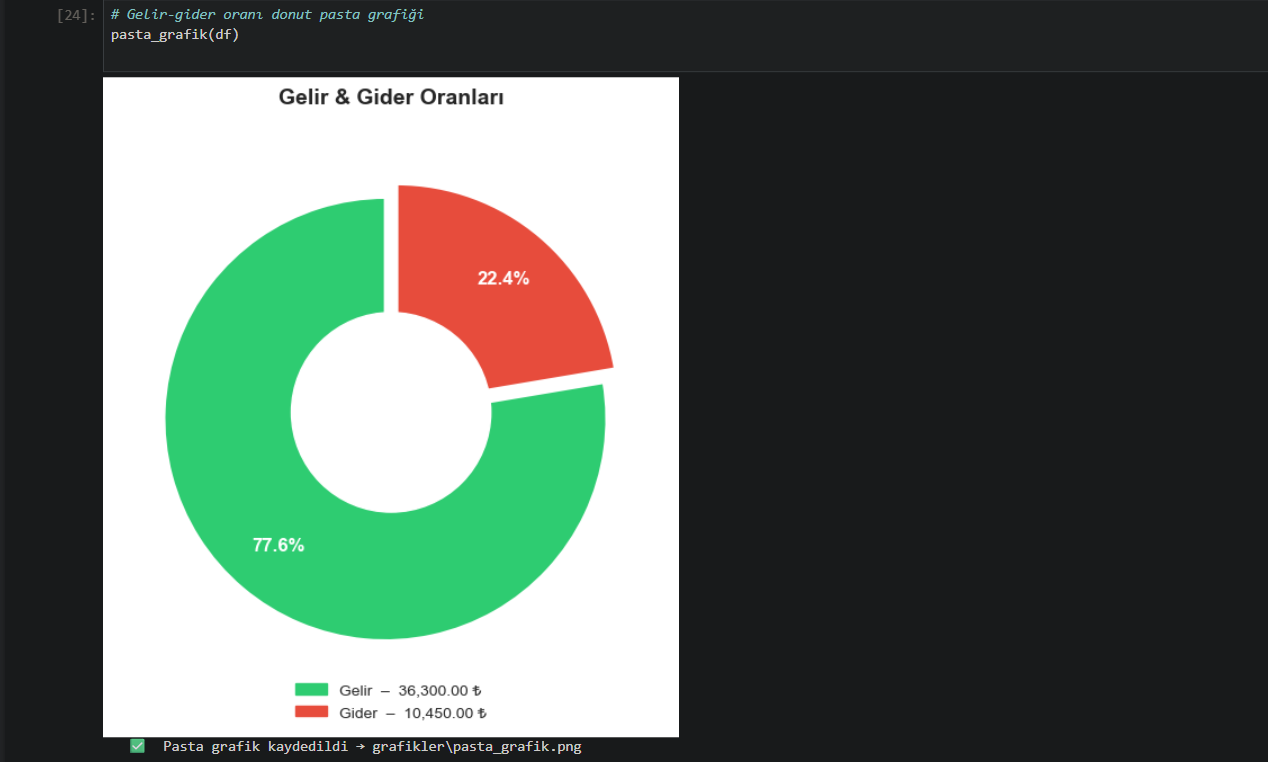)


## 13. CSV Kaydet

Güncel gelir ve gider listesi `csv_kaydet()` ile `veriler.csv` dosyasına yazılıyor.  
Bu dosya bir sonraki çalıştırmada otomatik yükleneceği için kaydetmeyi unutmamak önemli.


In [32]:
csv_kaydet(VERI_DOSYASI, gelirler, giderler)


  ✅  31 kayıt 'veriler.csv' dosyasına kaydedildi.


>  **Ekran Görüntüsü:** CSV kaydet fonksiyonu çalışıyor — 23 kayıt veriler.csv dosyasına yazıldı görseli:

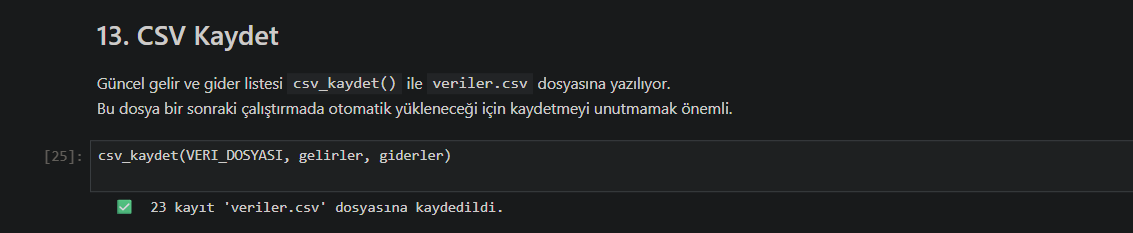)


## 14. İnteraktif Jupyter Menüsü

Aşağıdaki hücreyi çalıştırdığınızda **tam işlevli bir menü arayüzü** açılır.  
Jupyter'da `input()` düzgün çalışmadığı için menüyü **ipywidgets** ile yeniden tasarladım bunu yeni öğrendim ve daha profesyonel bulduğum için tercih ettim.  
Butonlara tıklayarak gelir ekleyebilir, gider ekleyebilir, silebilir, analiz yapabilir ve grafik gösterebilirsiniz.  

> **Not:** `python main.py` komutuyla klasik terminal menüsünü de kullanabilirsiniz.


In [20]:
# ============================================================
# Jupyter İnteraktif Menü – ipywidgets tabanlı
# Tüm işlemler bu tek hücre üzerinden yapılabilir.
# Hücre birden fazla kez çalıştırılsa bile tek arayüz görünür.
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Singleton guard: hücre tekrar çalışırsa eski widget temizlenir ────
try:
    _finans_widget_output.close()
except NameError:
    pass

_finans_widget_output = widgets.Output()

# ── Çıktı alanı ──────────────────────────────────────────────
cikti = widgets.Output(
    layout=widgets.Layout(border='1px solid #ddd', padding='10px',
                          min_height='120px', margin_top='8px')
)

# ── Form alanları ─────────────────────────────────────────────
stil = {'description_width': '130px'}
w_tutar    = widgets.FloatText(description='Tutar (TL):', style=stil,
                                layout=widgets.Layout(width='280px'))
w_tarih    = widgets.Text(description='Tarih:', placeholder='2026-06-01',
                           style=stil, layout=widgets.Layout(width='280px'))
w_aciklama = widgets.Text(description='Açıklama:', placeholder='kısa açıklama',
                           style=stil, layout=widgets.Layout(width='280px'))
w_sil_id   = widgets.IntText(description='Silinecek ID:', value=1, style=stil,
                               layout=widgets.Layout(width='240px'))

form_alanlari = widgets.VBox([w_tutar, w_tarih, w_aciklama])

# ── Buton tanımları ────────────────────────────────────────────
def buton(ad, renk='primary'):
    return widgets.Button(description=ad, button_style=renk,
                          layout=widgets.Layout(width='160px', height='36px'))

btn_gelir   = buton('+ Gelir Ekle',  'success')
btn_gider   = buton('+ Gider Ekle',  'danger')
btn_listele = buton('Listele',        'info')
btn_analiz  = buton('Analiz Yap',    'warning')
btn_grafik  = buton('Grafikleri Göster', 'primary')
btn_kaydet  = buton('CSV Kaydet',    '')
btn_sil     = buton('Sil (ID)',      'danger')

baslik = widgets.HTML(
    '<h3 style="margin:0;padding:8px 0;color:#2c3e50;"'
    '>💰 Kişisel Finans Takip Sistemi</h3>'
    '<hr style="margin:4px 0 10px 0;">'
)

# ── Yardımcı: DataFrame güncelle ──────────────────────────────
def guncelle_df():
    return verileri_dataframe_yap(gelirler, giderler)

# ── Gelir Ekle ────────────────────────────────────────────────
def gelir_ekle_cb(b):
    with cikti:
        clear_output()
        tutar = w_tutar.value
        tarih = w_tarih.value.strip()
        aciklama = w_aciklama.value.strip() or 'Açıklama girilmedi'
        if tutar <= 0:
            print('⚠  Tutar sıfırdan büyük olmalıdır.')
            return
        if not tarih_kontrol(tarih):
            print('⚠  Tarih formatı hatalı. Örnek: 2026-06-01')
            return
        yeni = Islem(yeni_id_olustur(gelirler), tutar, tarih, aciklama, 'gelir')
        gelirler.append(yeni)
        print(f'✅ Gelir kaydedildi: {yeni}')

# ── Gider Ekle ───────────────────────────────────────────────
def gider_ekle_cb(b):
    with cikti:
        clear_output()
        tutar = w_tutar.value
        tarih = w_tarih.value.strip()
        aciklama = w_aciklama.value.strip() or 'Açıklama girilmedi'
        if tutar <= 0:
            print('⚠  Tutar sıfırdan büyük olmalıdır.')
            return
        if not tarih_kontrol(tarih):
            print('⚠  Tarih formatı hatalı. Örnek: 2026-06-01')
            return
        yeni = Islem(yeni_id_olustur(giderler), tutar, tarih, aciklama, 'gider')
        giderler.append(yeni)
        print(f'✅ Gider kaydedildi: {yeni}')

# ── Listele ──────────────────────────────────────────────────
def listele_cb(b):
    with cikti:
        clear_output()
        islemleri_listele(gelirler, giderler)

# ── Analiz ───────────────────────────────────────────────────
def analiz_cb(b):
    with cikti:
        clear_output()
        df = guncelle_df()
        if df.empty:
            print('ℹ  Analiz için veri yok.')
            return
        t = toplam_gelir_gider(df)
        print(f'Toplam Gelir  : {t["toplam_gelir"]:>12,.2f} TL')
        print(f'Toplam Gider  : {t["toplam_gider"]:>12,.2f} TL')
        print(f'Net Bakiye    : {t["bakiye"]:>+12,.2f} TL')
        print()
        print('── Aylık Analiz ──')
        print(aylik_analiz(df).to_string())
        print()
        print('── NumPy İstatistikleri ──')
        ist = numpy_istatistik(df)
        for k, v in ist.items():
            print(f'  {k:<20}: {v:>10,.2f} TL')

# ── Grafik ───────────────────────────────────────────────────
def grafik_cb(b):
    with cikti:
        clear_output()
        df = guncelle_df()
        if df.empty:
            print('ℹ  Grafik için veri yok.')
            return
        aylik_grafik(df)
        gelir_gider_bar(df)
        pasta_grafik(df)

# ── CSV Kaydet ────────────────────────────────────────────────
def kaydet_cb(b):
    with cikti:
        clear_output()
        csv_kaydet(VERI_DOSYASI, gelirler, giderler)

# ── Sil ──────────────────────────────────────────────────────
def sil_cb(b):
    with cikti:
        clear_output()
        islem_sil(gelirler, giderler, w_sil_id.value)

# ── Callback bağlantıları ─────────────────────────────────────
btn_gelir.on_click(gelir_ekle_cb)
btn_gider.on_click(gider_ekle_cb)
btn_listele.on_click(listele_cb)
btn_analiz.on_click(analiz_cb)
btn_grafik.on_click(grafik_cb)
btn_kaydet.on_click(kaydet_cb)
btn_sil.on_click(sil_cb)

# ── Arayüz düzeni ─────────────────────────────────────────────
form_baslik = widgets.HTML('<b>Yeni İşlem Ekle</b>')
sil_baslik  = widgets.HTML('<b>İşlem Sil</b>')

sol_panel = widgets.VBox([
    form_baslik,
    form_alanlari,
    widgets.HBox([btn_gelir, btn_gider]),
    widgets.HTML('<hr style="margin:8px 0">'),
    sil_baslik,
    widgets.HBox([w_sil_id, btn_sil]),
], layout=widgets.Layout(padding='8px', min_width='340px'))

sag_panel = widgets.VBox([
    widgets.HTML('<b>İşlemler & Analizler</b>'),
    widgets.HBox([btn_listele, btn_analiz]),
    widgets.HBox([btn_grafik, btn_kaydet]),
], layout=widgets.Layout(padding='8px'))

ana_panel = widgets.HBox(
    [sol_panel, widgets.HTML('<div style="width:20px"></div>'), sag_panel],
    layout=widgets.Layout(border='2px solid #3498db', border_radius='8px',
                          padding='12px', background='#f8f9fa')
)

# ── Render: singleton output'a göster ─────────────────────────
with _finans_widget_output:
    clear_output(wait=True)
    display(widgets.VBox([baslik, ana_panel, cikti]))

display(_finans_widget_output)


Output()

> **Ekran Görüntüsü:** ipywidgets GUI arayüzü — tüm işlemler tek ekranda gösterimi burada :

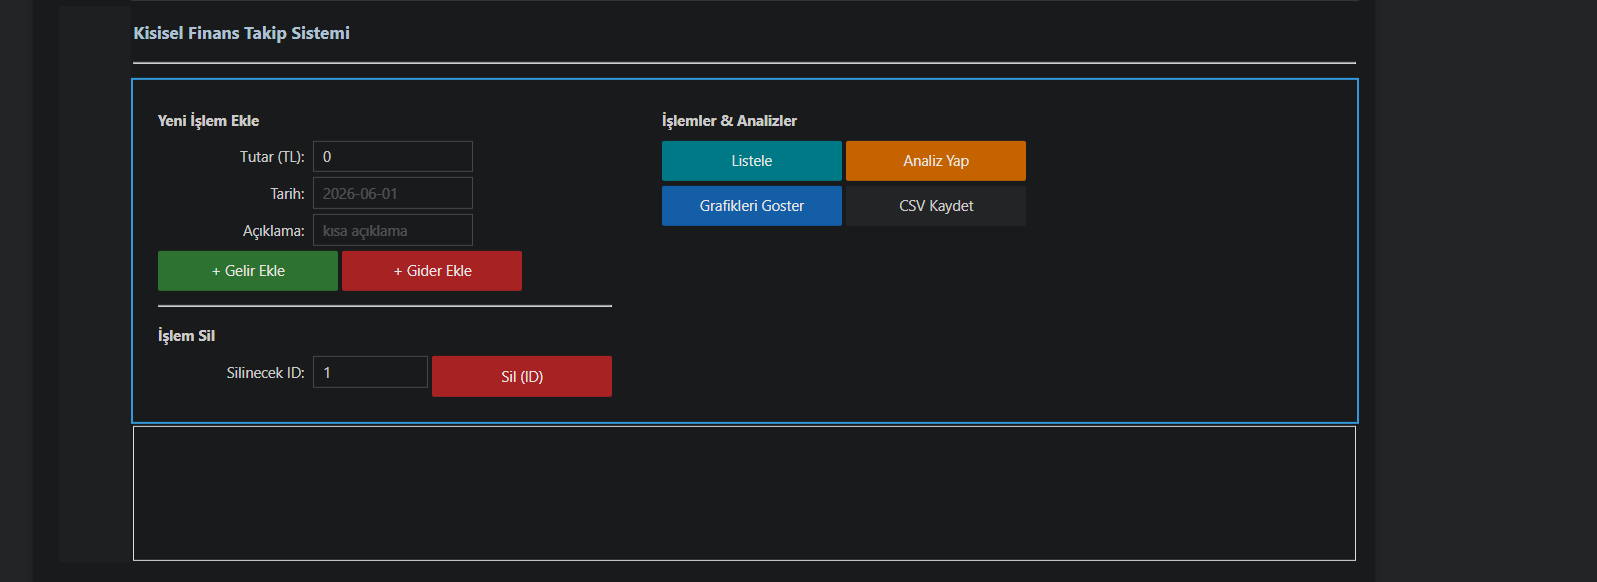)


## 15. GitHub ve Teslim Notu

- **Repo:** `24902005-MahmuthanErdinc-PythonProje` (Private)
- **Collaborator:** `tohid.yousefi`
- En az 4 açıklayıcı commit yapılmıştır.
- **GitHub Repo Linki:** https://github.com/Mahmuthann/24902005-MahmuthanErdinc-PythonProje
- Proje `.zip` formatında ALMS'ye yüklenmektedir.
